## Introduction

Social media has become a ubiquitous part of modern life, with platforms such as Instagram, Twitter, and Facebook serving as essential communication channels. Social media data sets are vast and complex, making analysis a challenging task for businesses and researchers alike. In this project, we explore a simulated social media, for example Tweets, data set to understand trends in likes across different categories.

## Prerequisites

To follow along with this project, you should have a basic understanding of Python programming and data analysis concepts. In addition, you may want to use the following packages in your Python environment:

- pandas
- Matplotlib
- ...

These packages should already be installed in Coursera's Jupyter Notebook environment, however if you'd like to install additional packages that are not included in this environment or are working off platform you can install additional packages using `!pip install packagename` within a notebook cell such as:

- `!pip install pandas`
- `!pip install matplotlib`

## Project Scope

The objective of this project is to analyze tweets (or other social media data) and gain insights into user engagement. We will explore the data set using visualization techniques to understand the distribution of likes across different categories. Finally, we will analyze the data to draw conclusions about the most popular categories and the overall engagement on the platform.

## Step 1: Importing Required Libraries

As the name suggests, the first step is to import all the necessary libraries that will be used in the project. In this case, we need pandas, numpy, matplotlib, seaborn, and random libraries.

Pandas is a library used for data manipulation and analysis. Numpy is a library used for numerical computations. Matplotlib is a library used for data visualization. Seaborn is a library used for statistical data visualization. Random is a library used to generate random numbers.

In [49]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import random
import missingno as msno

In [50]:
!pip install --upgrade seaborn
!pip install --upgrade pip
!pip install --upgrade missingno

# Clean & Analyze Social Media

In [4]:
df = pd.read_csv('social_media_usage.csv')

In [5]:
df.head()

,User_ID,App,Daily_Minutes_Spent,Posts_Per_Day,Likes_Per_Day,Follows_Per_Day
0,U_1,Pinterest,288,16,94,0
1,U_2,Facebook,192,14,117,15
2,U_3,Instagram,351,13,120,48
3,U_4,TikTok,21,20,117,8
4,U_5,LinkedIn,241,16,9,21


In [6]:
df.tail()

,User_ID,App,Daily_Minutes_Spent,Posts_Per_Day,Likes_Per_Day,Follows_Per_Day
995,U_996,LinkedIn,479,4,72,15
996,U_997,Instagram,499,14,110,49
997,U_998,Facebook,318,6,105,9
998,U_999,TikTok,305,15,151,6
999,U_1000,Pinterest,115,17,81,39


In [7]:
df.describe()

,Daily_Minutes_Spent,Posts_Per_Day,Likes_Per_Day,Follows_Per_Day
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,247.368000,10.269000,94.682000,24.698000
std,146.371921,6.121774,57.560943,14.842948
min,5.000000,0.000000,0.000000,0.000000
25%,112.750000,5.000000,44.750000,12.000000
50%,246.000000,10.000000,94.000000,24.000000
75%,380.500000,16.000000,142.000000,38.000000
max,500.000000,20.000000,200.000000,50.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   User_ID              1000 non-null   object
 1   App                  1000 non-null   object
 2   Daily_Minutes_Spent  1000 non-null   int64 
 3   Posts_Per_Day        1000 non-null   int64 
 4   Likes_Per_Day        1000 non-null   int64 
 5   Follows_Per_Day      1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB


In [9]:
df.shape

(1000, 6)

In [10]:
df.columns

Index(['User_ID', 'App', 'Daily_Minutes_Spent', 'Posts_Per_Day',
       'Likes_Per_Day', 'Follows_Per_Day'],
      dtype='object')

In [11]:
df.index

RangeIndex(start=0, stop=1000, step=1)

In [12]:
df.isnull().sum()

User_ID                0
App                    0
Daily_Minutes_Spent    0
Posts_Per_Day          0
Likes_Per_Day          0
Follows_Per_Day        0
dtype: int64

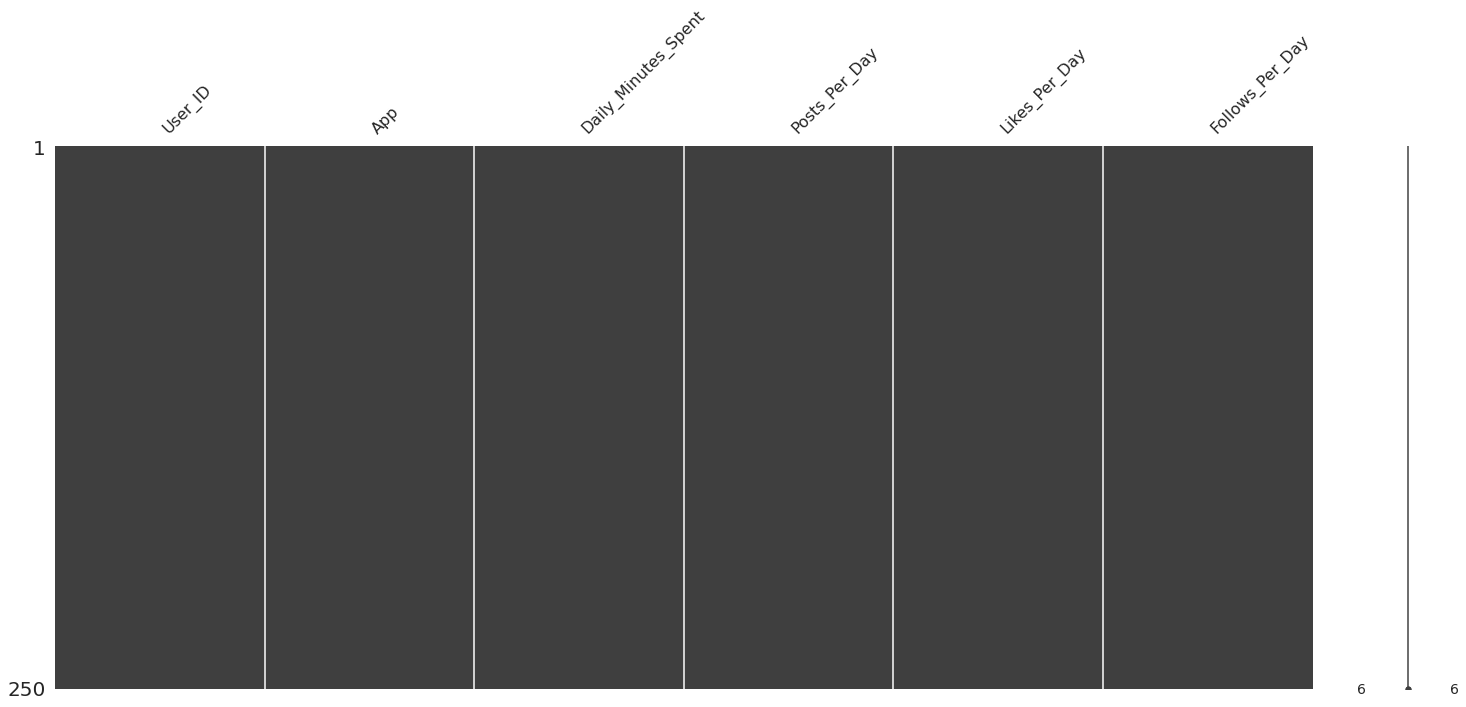

In [51]:
msno.matrix(df.sample(250))

In [13]:
df.duplicated().sum()

0

In [14]:
df.groupby('App')['Follows_Per_Day'].mean() 

App
Facebook     23.117647
Instagram    25.864286
LinkedIn     25.081633
Pinterest    24.792857
Snapchat     25.506410
TikTok       24.439716
Twitter      23.928571
Name: Follows_Per_Day, dtype: float64

In [15]:
df['App'].value_counts()

Snapchat     156
LinkedIn     147
TikTok       141
Instagram    140
Twitter      140
Pinterest    140
Facebook     136
Name: App, dtype: int64

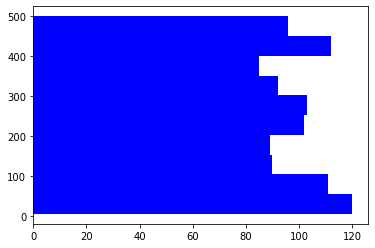

In [25]:
plt.hist(df['Daily_Minutes_Spent'],orientation = 'horizontal',histtype = 'bar', color ='blue')
plt.show()


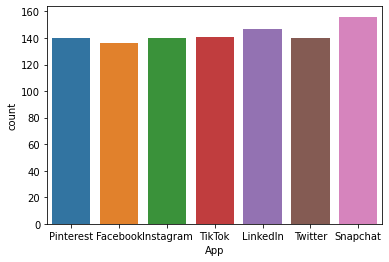

In [26]:
sns.countplot(x='App', data=df)

count    1000.000000
mean       10.269000
std         6.121774
min         0.000000
25%         5.000000
50%        10.000000
75%        16.000000
max        20.000000
Name: Posts_Per_Day, dtype: float64


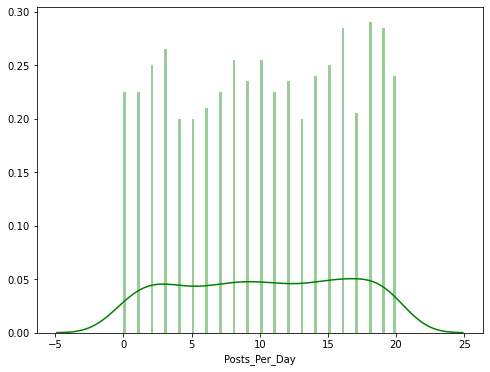

In [27]:
print(df['Posts_Per_Day'].describe())
plt.figure(figsize=(8, 6))
sns.distplot(df['Posts_Per_Day'], color='g', bins=100, hist_kws={'alpha': 0.4});

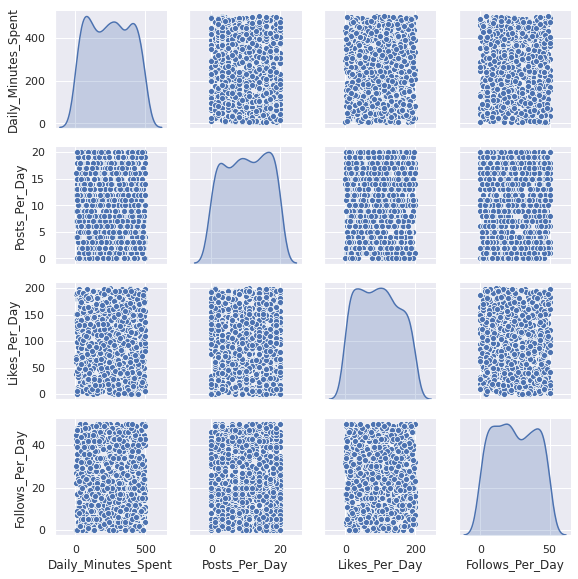

In [28]:
sns.set()
columns = ['App','Daily_Minutes_Spent','Posts_Per_Day','Likes_Per_Day','Follows_Per_Day']
sns.pairplot(df[columns],size = 2 ,kind ='scatter',diag_kind='kde')
plt.show()

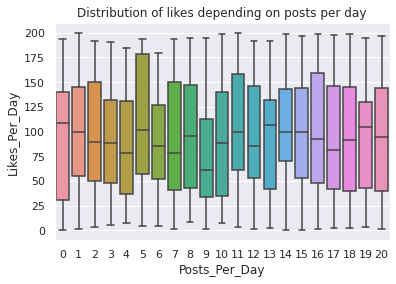

In [29]:
sns.boxplot(x='Posts_Per_Day', y='Likes_Per_Day', data=df)
plt.title("Distribution of likes depending on posts per day")
plt.show()

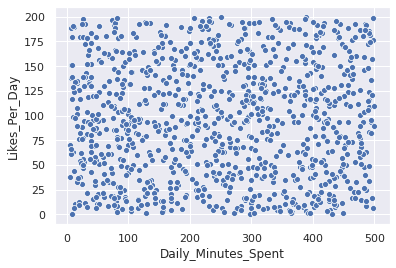

In [39]:
sns.scatterplot(x='Daily_Minutes_Spent', y='Likes_Per_Day', data=df)

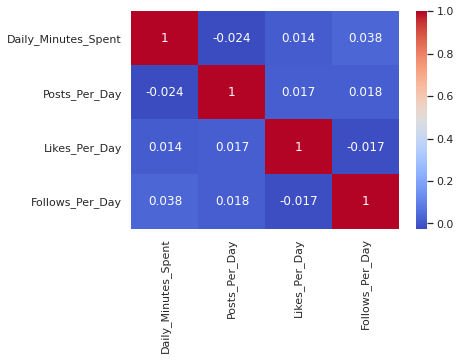

In [36]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

(0.0, 52.5)

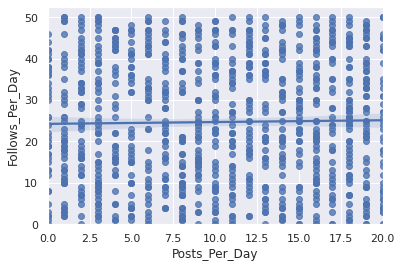

In [37]:
sns.regplot(x="Posts_Per_Day", y="Follows_Per_Day", data=df)
plt.ylim(0,)

In [58]:
df.skew(), df.kurt()

(Daily_Minutes_Spent    0.024168
 Posts_Per_Day         -0.058441
 Likes_Per_Day          0.100626
 Follows_Per_Day        0.036555
 dtype: float64,
 Daily_Minutes_Spent   -1.242722
 Posts_Per_Day         -1.231560
 Likes_Per_Day         -1.152417
 Follows_Per_Day       -1.232565
 dtype: float64)